<a href="https://colab.research.google.com/github/madhumita070507/ShadowFox/blob/Madhumita/Shadowfox(beginner).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

data=pd.read_csv("/content/sample_data/HousingData.csv")

In [ ]:
print(data.head())
#data preprocessing

data.fillna(data.mean(),inplace=True)

print( data.columns.tolist())
print(data.isnull().sum())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
target="MEDV"

x=data.drop(target,axis=1)
y=data[target]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

model=RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(x_train_scaled,y_train)


y_pred=model.predict(x_test_scaled)


In [ ]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print("Mean Squared Error :", mse)
print("r_squared :", r2)

RMSE: 2.874112792347798
MAE: 2.0666764705882357
Mean Squared Error : 8.260524343137256
r_squared : 0.8873571771815177


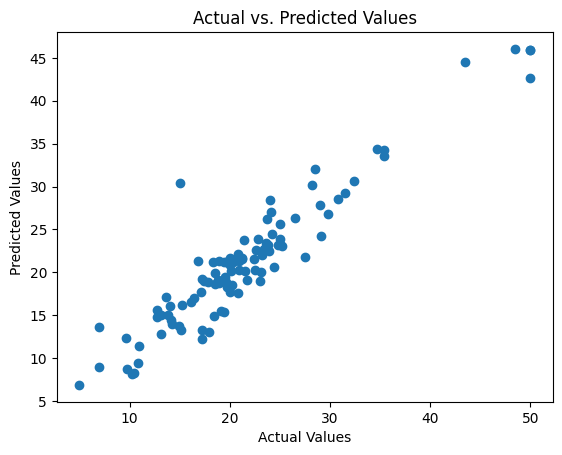

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

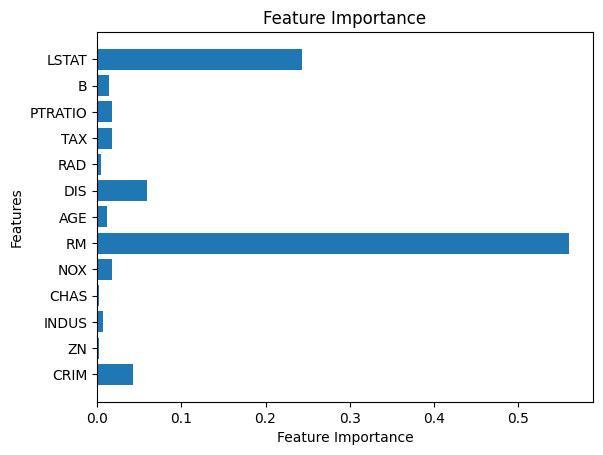

In [ ]:
impotance=model.feature_importances_
f_n=x.columns
plt.barh(f_n,impotance)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [ ]:
corr_with_target = data.corr()['MEDV'].abs().sort_values(ascending=False)

# Select top 6 features (excluding 'MEDV' itself)
top_features = corr_with_target[1:7].index.tolist()
print("Top features:", top_features)

# Redefine X and y
X = data[top_features]
y = data['MEDV']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
model=RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print("Mean Squared Error :", mse)
print("r_squared :", r2)

Top features: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']
RMSE: 3.400587456688648
MAE: 2.2984607843137175
Mean Squared Error : 11.563995050588169
r_squared : 0.842310125671454


In [ ]:
#hyperparameter for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, n_jobs=-1, scoring='r2')
grid_search.fit(x_train_scaled, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test_scaled)

print("Best R2:", r2_score(y_test, y_pred))

Best R2: 0.8483901644286076
